# Simulasi Dampak Penghapusan Diskon terhadap Profit Margin (Central)

## Metodologi

1. Memfilter data untuk region Central.
2. Menghitung profit margin aktual dan simulasi.
3. Memvisualisasikan hasil perhitungan.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('superstore.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], yearfirst=True, errors='coerce')

## Filter Data Region Central

Memfilter data untuk region Central sebagai fokus analisis.

In [2]:
df_central = df[df['region'] == 'Central'].copy()

## Hitung Profit Margin

Menghitung profit margin aktual dan simulasi untuk region Central (`df_central`).

In [3]:
# Menghitung profit margin aktual (data sebenarnya)
sales_actual =  df_central['sales'].sum()
profit_actual = df_central['profit'].sum()
profit_margin_actual = profit_actual / sales_actual * 100

# Menghitung cost
df_central['cost'] = df_central['sales'] - df_central['profit']

# Menghitung sales simulasi (kondisi diskon 0% untuk sub-category Bookcases, Tables, dan Furnishings)
df_central['sales_before_discount'] = df_central['sales'] / (1 - df_central['discount'])

# Menghitung profit simulasi menggunakan cost yang sama
df_central['profit_before_discount'] = df_central['sales_before_discount'] - df_central['cost']

# Memisahkan data untuk menghitung profit margin simulasi
df_central_excluded = df_central.loc[~df_central['sub_category'].isin(['Bookcases', 'Tables', 'Furnishings'])].copy()
df_central_targeted = df_central.loc[df_central['sub_category'].isin(['Bookcases', 'Tables', 'Furnishings'])].copy()

# Menghitung profit margin simulasi 
sales_simulation = df_central_excluded['sales'].sum() + df_central_targeted['sales_before_discount'].sum()
profit_simulation = df_central_excluded['profit'].sum() + df_central_targeted['profit_before_discount'].sum()
profit_margin_simulation = profit_simulation / sales_simulation * 100

## Visualisasi Profit Margin

Memvisualisasikan hasil perhitungan dalam bentuk bar chart untuk menunjukkan perubahan profit margin.

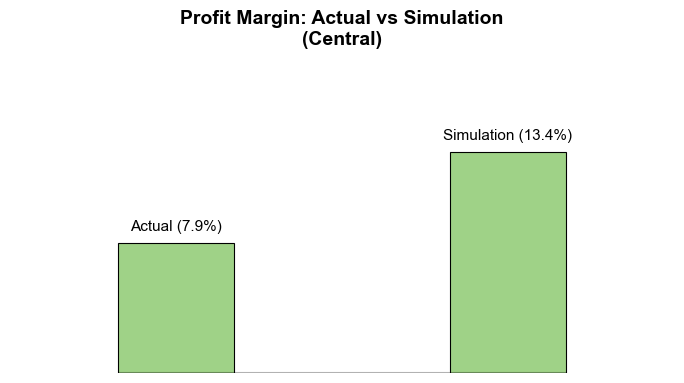

In [4]:
label_list = ['Actual', 'Simulation']
profit_margin_list = [profit_margin_actual, profit_margin_simulation]
palette = ['#9ADE7B' if margin > 0 else '#FF6868' for margin in profit_margin_list]

sns.set_theme(style='white')
plt.figure(figsize=(7, 4))

fig = sns.barplot(x=label_list, y=profit_margin_list, palette=palette, ec='black', ls='-', lw=0.8)

for bar in fig.patches:
    bar.set_width(0.35)
    bar.set_xy((bar.get_xy()[0] + 0.225, 0))

title_dict = {'size':14,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':0,
              'alpha':1,
              'family':plt.rcParams['font.family']}

plt.title('Profit Margin: Actual vs Simulation\n(Central)', **title_dict)

ax = plt.gca()
ax.set_ylim(0, 20)
ax.set_yticks(ticks=[])
ax.set_xticks(ticks=[])
ax.axhline(y=0.032, xmin=0.162, xmax=0.838, color='black', ls='-', lw=0.8, alpha=0.3)

container = ax.containers[0]
labels = [f'{label} ({margin:.1f}%)' for label, margin in zip(label_list, profit_margin_list)]
ax.bar_label(container=container, labels=labels, size=11, weight='normal', color='black', padding=7)

plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.show()